In [1]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
widget = pd.read_csv("/content/drive/MyDrive/2026/Time Series Analysis/Dataset/widget_sales.csv")

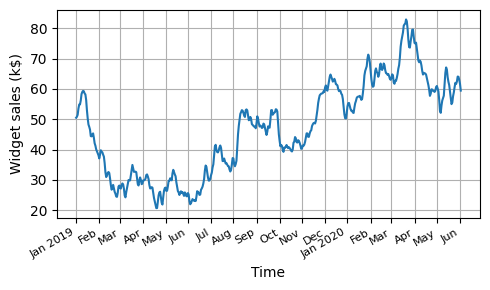

In [21]:
fig, ax = plt.subplots(figsize = (5, 3))

ax.plot(widget['widget_sales'])
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (k$)')

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498],
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'],
    fontsize = 8)

plt.grid(True)
fig.autofmt_xdate()
plt.tight_layout()

In [23]:
from statsmodels.tsa.stattools import adfuller

ADF_result = adfuller(widget['widget_sales'])
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')
if ADF_result[1] <= 0.05:
  print('The series is stationary')
else:
  print('The series is non-stationary')

ADF Statistic: -1.5121662069359048
p-value: 0.5274845352272605
The series is non-stationary


In [25]:
widget_sales_diff = np.diff(widget['widget_sales'], n=1)

ADF_result = adfuller(widget_sales_diff)
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

if ADF_result[1] <= 0.05:
  print('The series is stationary')
else:
  print('The series is non-stationary')

ADF Statistic: -10.576657780341959
p-value: 7.076922818587193e-19
The series is stationary


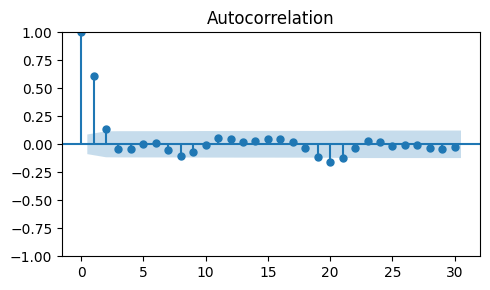

In [29]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(5, 3))
plot_acf(widget_sales_diff, lags=30, ax=ax)

plt.tight_layout()
plt.show()

#### **Interpretation**
the coefficients are significant up until lag 2, and then they fall abruptly into the non-significance zone. There are some significant coefficients around lag 20, but this is likely due to chance, since they are non-significant between lags 3 and 20 and after lag 20.
<br>So this is MA(2).

In [30]:
df_diff = pd.DataFrame({'widget_sales_diff': widget_sales_diff})

# Split train test into 90:10
train = df_diff[:int(0.9*len(df_diff))]
test = df_diff[int(0.9*len(df_diff)):]

print(len(train))
print(len(test))

449
50


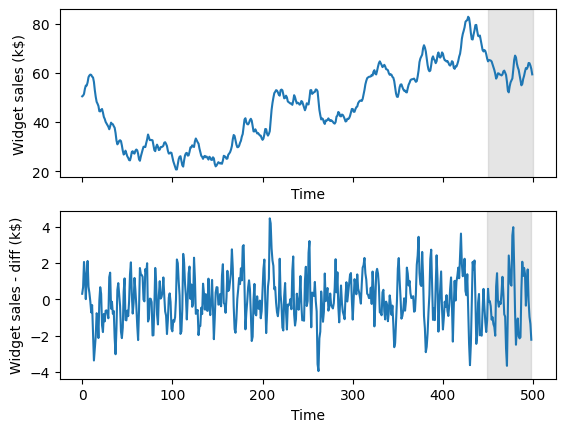

In [32]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)
ax1.plot(widget['widget_sales'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Widget sales (k$)')
ax1.axvspan(450, 500, color='#808080', alpha=0.2)
ax2.plot(df_diff['widget_sales_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Widget sales - diff (k$)')
ax2.axvspan(449, 498, color='#808080', alpha=0.2)
plt.show()

## **Forecasting using MA Model**

In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [36]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int,window: int, method: str) -> list:
  total_len = train_len + horizon
  if method == 'mean':
    pred_mean = []

    for i in range(train_len, total_len, window):
      mean = np.mean(df[:i].values)
      pred_mean.extend(mean for _ in range(window))

    return pred_mean
  elif method == 'last':
    pred_last_value = []
    for i in range(train_len, total_len, window):
      last_value = df[:i].iloc[-1].values[0]
      pred_last_value.extend(last_value for _ in range(window))
    return pred_last_value

  elif method == 'MA':
    pred_MA = []
  for i in range(train_len, total_len, window):
    model = SARIMAX(df[:i], order=(0,0,2))
    res = model.fit(disp=False)
    predictions = res.get_prediction(0, i + window - 1)
    oos_pred = predictions.predicted_mean.iloc[-window:]
    pred_MA.extend(oos_pred)
  return pred_MA

In [37]:
pred_df = test.copy()
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_MA = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'MA')
pred_df['pred_mean'] = pred_mean
pred_df['pred_last_value'] = pred_last_value
pred_df['pred_MA'] = pred_MA
pred_df.head()

,widget_sales_diff,pred_mean,pred_last_value,pred_MA
449,-1.170131,0.034319,-1.803658,-1.078833
450,0.580967,0.034319,-1.803658,-0.273309
451,-0.144902,0.032861,0.580967,0.781223
452,-0.096564,0.032861,0.580967,0.234969
453,-0.372334,0.032183,-0.096564,0.168994


In [38]:
from sklearn.metrics import mean_squared_error
mse_mean = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_mean'])
mse_last = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_last_value'])
mse_MA = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_MA'])
print(mse_mean, mse_last, mse_MA)

2.5606299456880537 3.2494260812249225 1.9481714497863145


In [39]:
# Initialize an empty column to hold our predictions.
widget['pred_widget_sales'] = pd.Series()

# Inverse-transform the predictions to bring them back to the original scale of the dataset.
widget['pred_widget_sales'][450:] = widget['widget_sales'].iloc[450] + pred_df['pred_MA'].cumsum()

/tmp/ipython-input-338/2750968712.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  widget['pred_widget_sales'][450:] = widget['widget_sales'].iloc[450] + pred_df['pred_MA'].cumsum()
/tmp/ipython-input-338/2750968712.py:5: SettingWithCopyW

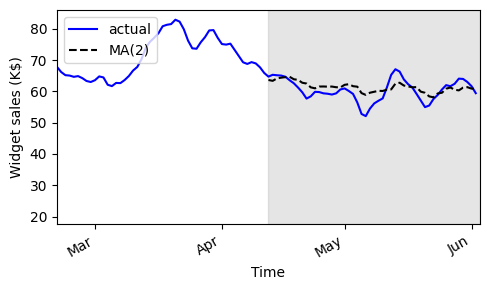

In [41]:
fig, ax = plt.subplots(figsize = (5, 3))
ax.plot(widget['widget_sales'], 'b-', label='actual')
ax.plot(widget['pred_widget_sales'], 'k--', label='MA(2)')
ax.legend(loc=2)
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (K$)')
ax.axvspan(450, 500, color='#808080', alpha=0.2)
ax.set_xlim(400, 500)
plt.xticks(
[409, 439, 468, 498],
['Mar', 'Apr', 'May', 'Jun'])
fig.autofmt_xdate()
plt.tight_layout()

In [43]:
from sklearn.metrics import mean_absolute_error

mae_MA_undiff = mean_absolute_error(widget['widget_sales'].iloc[450:], widget['pred_widget_sales'].iloc[450:])
print(mae_MA_undiff)

2.324470924451404
